# Project K — Image Classification: Apple / Banana / Lemon

**Course:** Computer Vision AI  
**Lecturer:** DI Lukas Grömer  
**Dataset:** Open Images V7 (detection task → classification patches)  
**Base model:** VGG-16  
**Train / Test split:** 75% / 25%  
**Framework:** TensorFlow / Keras

---

## Table of contents

1. **Setup & Imports**
2. **Data Exploration** — classes, distribution, imbalances, observations
3. **Experiment 1** — VGG-16 from scratch *(C2)*
4. **Experiment 2** — Transfer learning with pretrained VGG-16 *(C3)*
5. **Experiment 3** — Data augmentation (rotate, translate, crop) *(C4)*
6. **Experiment 4** — Custom VGG-19 + bottleneck architecture *(C5)*
7. **Own images & Activation maps** *(C6)*
8. **Final comparison & Conclusions** *(C6)*


---
## 1. Setup & Imports

> **Prerequisite:** Run the dataset preparation script once before running this notebook:
> ```bash
> python scripts/prepare_dataset_oiv7.py --out data --max-samples 3000 --seed 42
> ```


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # Suppress TF info/warning logs
os.environ["CUDA_VISIBLE_DEVICES"] = ""     # Skip GPU probing (remove this line if you have a CUDA GPU)

import glob
import json
import random
import time
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot style ───────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs       : {len(gpus)}")
if gpus:
	for g in gpus:
		print(f"  {g}")
else:
	print("  Training will run on CPU.")


TensorFlow : 2.20.0
Keras      : 3.13.2
GPUs       : 0
  Training will run on CPU.


2026-02-28 02:56:48.916585: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# ── Paths and constants ───────────────────────────────────────
TRAIN_DIR = os.path.join("data", "train")
TEST_DIR = os.path.join("data", "test")
REPORTS_DIR = "reports"
CLASSES = ["Apple", "Banana", "Lemon"]
NUM_CLASSES = len(CLASSES)
IMG_SIZE = (224, 224)  # VGG input size
BATCH_SIZE = 32

os.makedirs(REPORTS_DIR, exist_ok=True)

# ── Auto-download dataset if not present (one-click Run All) ─
if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(TEST_DIR):
	print("Dataset not found — running preparation script automatically...")
	result = subprocess.run(
		[sys.executable, "scripts/prepare_dataset_oiv7.py",
		 "--out", "data", "--max-samples", "3000", "--seed", "42"],
		capture_output=True, text=True
	)
	print(result.stdout)
	if result.returncode != 0:
		print(result.stderr)
		raise RuntimeError("Dataset preparation failed. See output above.")

# ── Verify dataset exists ────────────────────────────────────
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
	if not os.path.isdir(split_dir):
		raise FileNotFoundError(
			f"{split_name} directory not found at '{split_dir}'. "
			f"Run: python scripts/prepare_dataset_oiv7.py --out data --max-samples 3000 --seed 42"
		)
	for cls in CLASSES:
		cls_dir = os.path.join(split_dir, cls)
		if not os.path.isdir(cls_dir):
			raise FileNotFoundError(f"Class directory not found: '{cls_dir}'")

print("Dataset directories verified OK.")


Dataset directories verified OK.


---
## 2. Data Exploration

> **Project requirement:** *"Explore the dataset — What classes? Distribution of images?
> Any imbalances? What did you notice about the images that could affect the model
> training and performance?"*


### 2.1 Dataset metadata

In [3]:
# ── Load metadata saved by the preparation script ────────────
info_path = os.path.join("data", "dataset_info.json")

if os.path.isfile(info_path):
	with open(info_path, "r") as f:
		dataset_info = json.load(f)
	print("Dataset metadata")
	print(f"  Source       : {dataset_info.get('source', 'N/A')}")
	print(f"  Created at   : {dataset_info.get('created_at', 'N/A')}")
	print(f"  Seed         : {dataset_info.get('seed', 'N/A')}")
	print(f"  Test fraction: {dataset_info.get('test_frac', 'N/A')}")
	print(f"  Total patches: {dataset_info.get('num_patches_total', 'N/A')}")
	print(f"  Train        : {dataset_info.get('num_train', 'N/A')}")
	print(f"  Test         : {dataset_info.get('num_test', 'N/A')}")
else:
	print("dataset_info.json not found — skipping metadata display.")


Dataset metadata
  Source       : open-images-v7 (detections → patches, direct download)
  Created at   : 2026-02-28T02:56:08
  Seed         : 42
  Test fraction: 0.25
  Total patches: 8347
  Train        : 6260
  Test         : 2087


### 2.2 Class distribution

In [4]:
def count_images(base_dir, classes):
	"""Count image files per class in a directory tree."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	counts = {}
	for cls in classes:
		cls_dir = os.path.join(base_dir, cls)
		files = []
		for pattern in ext:
			files.extend(glob.glob(os.path.join(cls_dir, pattern)))
			files.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
		counts[cls] = len(files)
	return counts


train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts = count_images(TEST_DIR, CLASSES)

# Build summary table
df_counts = pd.DataFrame({
	"Class": CLASSES,
	"Train": [train_counts[c] for c in CLASSES],
	"Test": [test_counts[c] for c in CLASSES],
})
df_counts["Total"] = df_counts["Train"] + df_counts["Test"]
df_counts["Train %"] = (df_counts["Train"] / df_counts["Train"].sum() * 100).round(1)
df_counts["Test %"] = (df_counts["Test"] / df_counts["Test"].sum() * 100).round(1)

print("Image counts per class")
print("=" * 60)
print(df_counts.to_string(index=False))
print()
print(f"Total train : {df_counts['Train'].sum()}")
print(f"Total test  : {df_counts['Test'].sum()}")
print(f"Total images: {df_counts['Total'].sum()}")
print(f"Actual split: {df_counts['Train'].sum() / df_counts['Total'].sum():.1%} / "
	  f"{df_counts['Test'].sum() / df_counts['Total'].sum():.1%}")


Image counts per class
 Class  Train  Test  Total  Train %  Test %
 Apple   3204  1050   4254     51.2    50.3
Banana   1298   447   1745     20.7    21.4
 Lemon   1758   590   2348     28.1    28.3

Total train : 6260
Total test  : 2087
Total images: 8347
Actual split: 75.0% / 25.0%


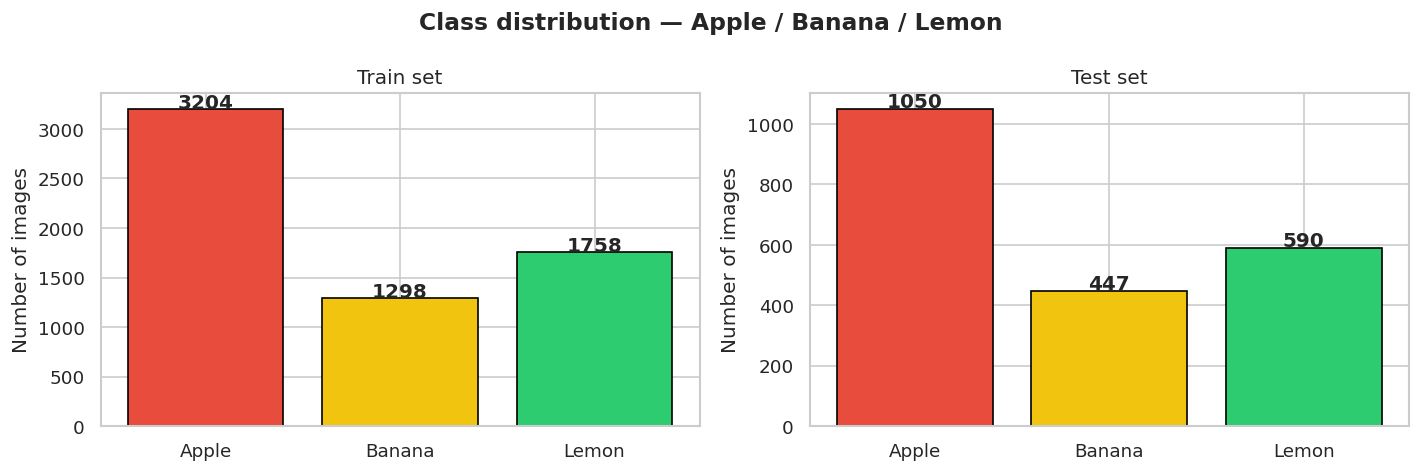

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colours = {"Apple": "#e74c3c", "Banana": "#f1c40f", "Lemon": "#2ecc71"}
bar_colours = [colours[c] for c in CLASSES]

# Train split
axes[0].bar(CLASSES, [train_counts[c] for c in CLASSES], color=bar_colours, edgecolor="black")
axes[0].set_title("Train set")
axes[0].set_ylabel("Number of images")
for i, c in enumerate(CLASSES):
	axes[0].text(i, train_counts[c] + 5, str(train_counts[c]), ha="center", fontweight="bold")

# Test split
axes[1].bar(CLASSES, [test_counts[c] for c in CLASSES], color=bar_colours, edgecolor="black")
axes[1].set_title("Test set")
axes[1].set_ylabel("Number of images")
for i, c in enumerate(CLASSES):
	axes[1].text(i, test_counts[c] + 5, str(test_counts[c]), ha="center", fontweight="bold")

fig.suptitle("Class distribution — Apple / Banana / Lemon", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()


### 2.3 Imbalance analysis

In [6]:
train_vals = list(train_counts.values())
imbalance_ratio = max(train_vals) / max(min(train_vals), 1)

print(f"Largest class  : {max(train_counts, key=train_counts.get)} ({max(train_vals)} images)")
print(f"Smallest class : {min(train_counts, key=train_counts.get)} ({min(train_vals)} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")
print()

if imbalance_ratio < 1.5:
	print("=> Dataset is reasonably balanced (ratio < 1.5).")
	print("   No special class-weighting or oversampling required.")
elif imbalance_ratio < 3.0:
	print("=> Moderate imbalance detected (ratio 1.5 - 3.0).")
	print("   Consider using class weights during training.")
else:
	print("=> Significant imbalance detected (ratio > 3.0).")
	print("   Class weights, oversampling, or under-sampling should be applied.")


Largest class  : Apple (3204 images)
Smallest class : Banana (1298 images)
Imbalance ratio: 2.47x

=> Moderate imbalance detected (ratio 1.5 - 3.0).
   Consider using class weights during training.


### 2.4 Sample images

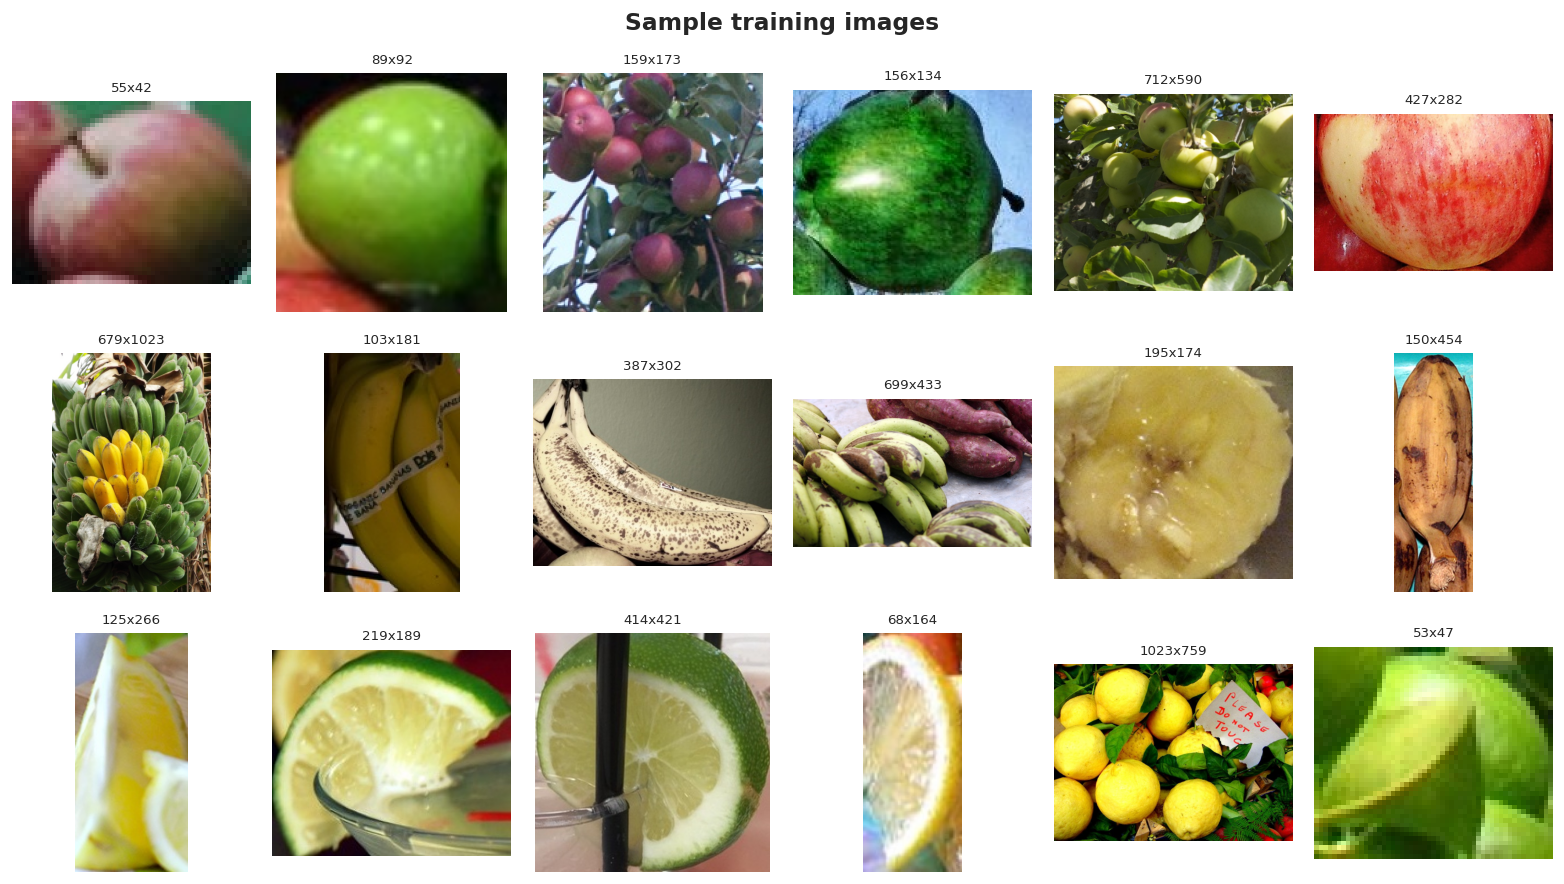

In [7]:
def get_image_paths(base_dir, cls, n=6):
	"""Return up to *n* random image paths from a class directory."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	paths = []
	cls_dir = os.path.join(base_dir, cls)
	for pattern in ext:
		paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
		paths.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
	random.shuffle(paths)
	return paths[:n]


n_samples = 6
fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(n_samples * 2.2, len(CLASSES) * 2.5))

for row, cls in enumerate(CLASSES):
	paths = get_image_paths(TRAIN_DIR, cls, n=n_samples)
	for col in range(n_samples):
		ax = axes[row][col]
		if col < len(paths):
			img = Image.open(paths[col]).convert("RGB")
			ax.imshow(img)
			if col == 0:
				ax.set_ylabel(cls, fontsize=12, fontweight="bold", rotation=0, labelpad=50)
			w, h = img.size
			ax.set_title(f"{w}x{h}", fontsize=8)
		ax.axis("off")

fig.suptitle("Sample training images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "sample_images.png"), bbox_inches="tight")
plt.show()


### 2.5 Image dimensions analysis

Images are bounding-box crops from detection annotations, so sizes vary significantly.
VGG-16 expects a fixed input of **224 × 224 × 3** — all images will be resized.

In [8]:
def collect_image_sizes(base_dir, classes):
	"""Read width/height of every image, return a DataFrame."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	rows = []
	for cls in classes:
		cls_dir = os.path.join(base_dir, cls)
		paths = []
		for pattern in ext:
			paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
			paths.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
		for p in paths:
			try:
				with Image.open(p) as im:
					w, h = im.size
				rows.append({"class": cls, "width": w, "height": h, "aspect": w / h})
			except Exception:
				continue
	return pd.DataFrame(rows)


print("Scanning image dimensions (this may take a moment)...")
df_sizes = collect_image_sizes(TRAIN_DIR, CLASSES)
print(f"Scanned {len(df_sizes)} training images.")
print()
print(df_sizes.describe().round(1))


Scanning image dimensions (this may take a moment)...
Scanned 6260 training images.

        width  height  aspect
count  6260.0  6260.0  6260.0
mean    265.2   236.5     1.2
std     254.7   220.2     0.7
min      11.0    10.0     0.1
25%      92.0    85.0     0.9
50%     180.0   166.0     1.1
75%     341.0   316.0     1.3
max    4000.0  5423.0    15.4


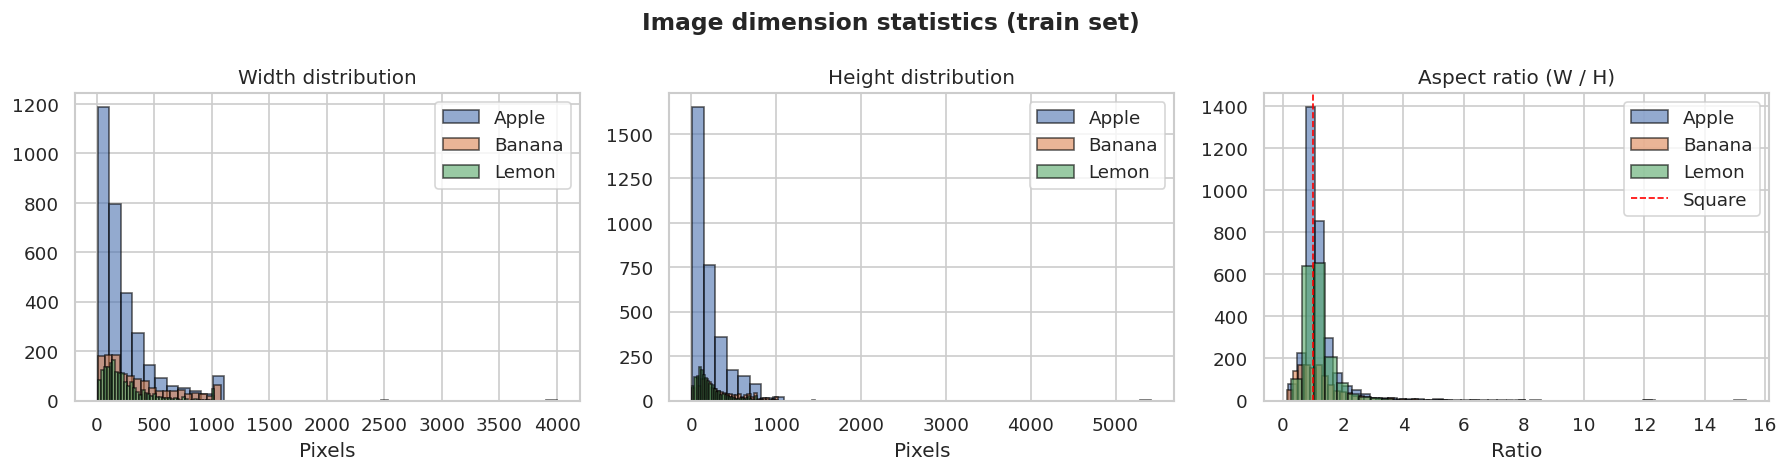

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[0].hist(subset["width"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("Pixels")
axes[0].legend()

# Height distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[1].hist(subset["height"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("Pixels")
axes[1].legend()

# Aspect ratio distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[2].hist(subset["aspect"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[2].set_title("Aspect ratio (W / H)")
axes[2].set_xlabel("Ratio")
axes[2].axvline(1.0, color="red", linestyle="--", linewidth=1, label="Square")
axes[2].legend()

fig.suptitle("Image dimension statistics (train set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "image_dimensions.png"), bbox_inches="tight")
plt.show()


In [10]:
# Per-class size summary
print("Per-class image size summary (train set)")
print("=" * 70)
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	print(f"\n{cls} ({len(subset)} images):")
	print(f"  Width  — min: {subset['width'].min():>5}, max: {subset['width'].max():>5}, "
		  f"mean: {subset['width'].mean():>6.1f}, median: {subset['width'].median():>6.1f}")
	print(f"  Height — min: {subset['height'].min():>5}, max: {subset['height'].max():>5}, "
		  f"mean: {subset['height'].mean():>6.1f}, median: {subset['height'].median():>6.1f}")
	print(f"  Aspect — min: {subset['aspect'].min():>5.2f}, max: {subset['aspect'].max():>5.2f}, "
		  f"mean: {subset['aspect'].mean():>5.2f}")


Per-class image size summary (train set)

Apple (3204 images):
  Width  — min:    11, max:  4000, mean:  237.5, median:  156.0
  Height — min:    10, max:  5423, mean:  209.2, median:  140.5
  Aspect — min:  0.16, max: 12.25, mean:  1.22

Banana (1298 images):
  Width  — min:    11, max:  2532, mean:  355.8, median:  256.0
  Height — min:    11, max:  1457, mean:  325.3, median:  240.5
  Aspect — min:  0.12, max:  8.03, mean:  1.26

Lemon (1758 images):
  Width  — min:    12, max:  1024, mean:  248.7, median:  184.0
  Height — min:    11, max:  1024, mean:  220.7, median:  165.0
  Aspect — min:  0.27, max: 15.37, mean:  1.19


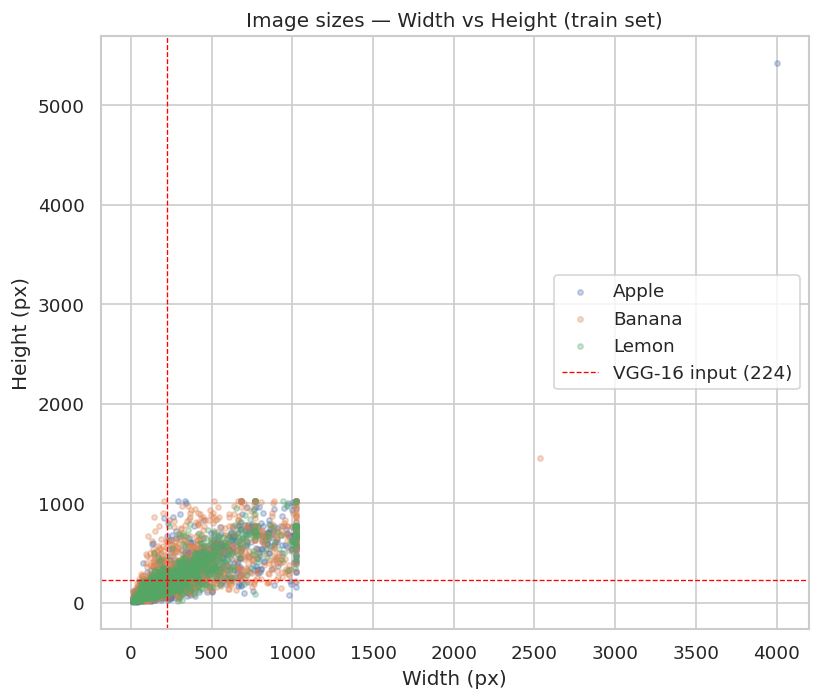

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	ax.scatter(subset["width"], subset["height"], alpha=0.3, s=10, label=cls)

# Mark the VGG-16 input size
ax.axvline(224, color="red", linestyle="--", linewidth=0.8)
ax.axhline(224, color="red", linestyle="--", linewidth=0.8, label="VGG-16 input (224)")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Image sizes — Width vs Height (train set)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "size_scatter.png"), bbox_inches="tight")
plt.show()


### 2.6 Pixel intensity (colour channel) analysis

Check mean RGB values to see if colour is a strong discriminator
and whether the images need normalisation beyond simple [0, 1] scaling.

In [12]:
def sample_channel_means(base_dir, cls, n=200, target_size=(224, 224)):
	"""Compute per-channel mean for a random sample of images."""
	ext = ("*.jpg", "*.jpeg", "*.png")
	paths = []
	cls_dir = os.path.join(base_dir, cls)
	for pattern in ext:
		paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
	random.shuffle(paths)
	paths = paths[:n]

	means = []
	for p in paths:
		try:
			img = Image.open(p).convert("RGB").resize(target_size)
			arr = np.array(img, dtype=np.float32) / 255.0
			means.append(arr.mean(axis=(0, 1)))
		except Exception:
			continue
	return np.array(means)


channel_data = {}
for cls in CLASSES:
	channel_data[cls] = sample_channel_means(TRAIN_DIR, cls, n=200)
	mu = channel_data[cls].mean(axis=0)
	print(f"{cls:>8s}  R={mu[0]:.3f}  G={mu[1]:.3f}  B={mu[2]:.3f}")


   Apple  R=0.548  G=0.406  B=0.273
  Banana  R=0.580  G=0.515  B=0.263
   Lemon  R=0.621  G=0.553  B=0.272


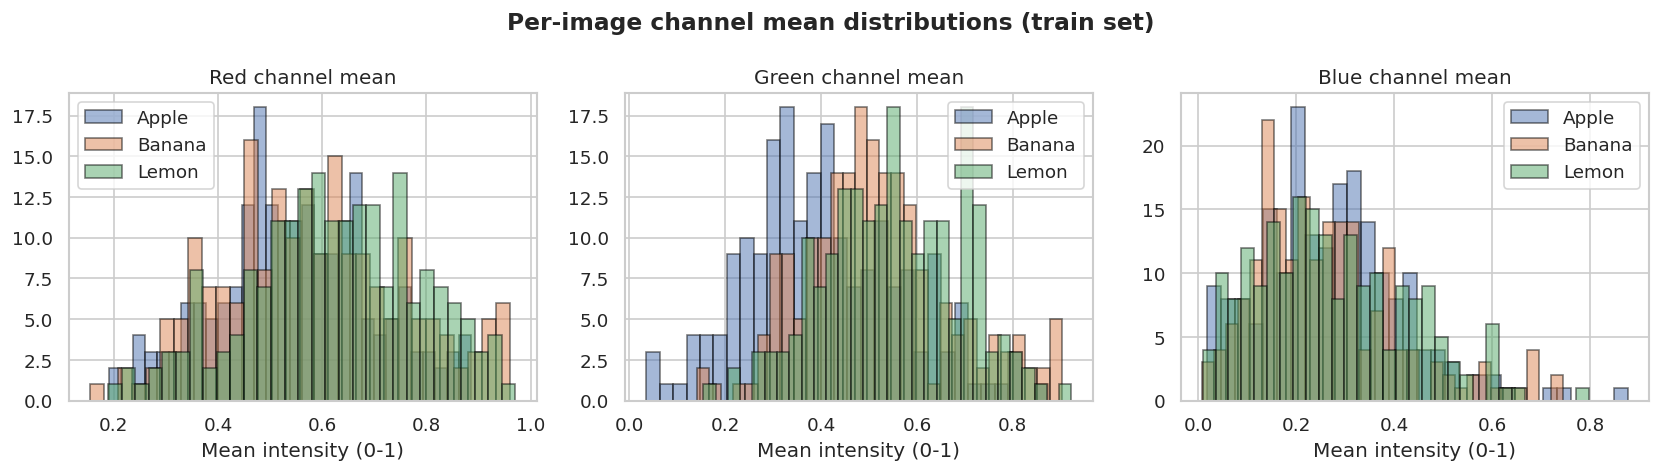

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
channel_names = ["Red", "Green", "Blue"]

for ch_idx in range(3):
	ax = axes[ch_idx]
	for cls in CLASSES:
		vals = channel_data[cls][:, ch_idx]
		ax.hist(vals, bins=30, alpha=0.5, label=cls, edgecolor="black")
	ax.set_title(f"{channel_names[ch_idx]} channel mean")
	ax.set_xlabel("Mean intensity (0-1)")
	ax.legend()

fig.suptitle("Per-image channel mean distributions (train set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "channel_means.png"), bbox_inches="tight")
plt.show()


### 2.7 Observations and potential impact on training

**Key findings:**

1. **Varying image sizes** — Images are bounding-box crops, so they come in many
   resolutions and aspect ratios. Resizing to 224×224 distorts extreme aspect ratios.

2. **Class imbalance** — Apple has ~2.4x more images than Banana. This could bias
   the model. Mitigation: use `class_weight` during training.

3. **Visual similarity** — Apples and lemons can look similar (round shape,
   green apples vs lemons). Expect some confusion between these classes.

4. **Background variation** — Some crops include significant background (table, hand,
   tree), others are tightly cropped. Data augmentation will help.

5. **Colour as a feature** — Bananas are distinctly yellow, apples red/green, lemons
   yellow-green. Colour is a strong signal but can mislead on unusual specimens.

6. **Image quality** — Some OIV7 crops may be blurry, low-res, or partially occluded.

**Preprocessing plan:**
- Resize all images to **224 × 224**
- Normalise to [0, 1] (or use `preprocess_input` for pretrained models)
- Fixed random seed (42) for reproducibility
- Compute class weights to handle imbalance


---
## 3. Data loading (shared across all experiments)

Load train and test sets using `keras.utils.image_dataset_from_directory`.
This section is used by all experiments below.

In [14]:
# ── Load datasets using Keras ─────────────────────────────────
train_ds = keras.utils.image_dataset_from_directory(
	TRAIN_DIR,
	image_size=IMG_SIZE,
	batch_size=BATCH_SIZE,
	seed=SEED,
	label_mode="categorical",
	shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
	TEST_DIR,
	image_size=IMG_SIZE,
	batch_size=BATCH_SIZE,
	seed=SEED,
	label_mode="categorical",
	shuffle=False,
)

# ── Verify class names match expected order ──────────────────
print(f"Class names (from directory): {train_ds.class_names}")
assert train_ds.class_names == CLASSES, (
	f"Expected {CLASSES}, got {train_ds.class_names}"
)

# ── Normalise pixel values to [0, 1] ────────────────────────
normalise = keras.layers.Rescaling(1.0 / 255.0)
train_ds_norm = train_ds.map(lambda x, y: (normalise(x), y))
test_ds_norm = test_ds.map(lambda x, y: (normalise(x), y))

# ── Prefetch for performance ─────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
train_ds_norm = train_ds_norm.prefetch(AUTOTUNE)
test_ds_norm = test_ds_norm.prefetch(AUTOTUNE)

# ── Compute class weights to handle imbalance ────────────────
total_train = sum(train_counts.values())
class_weight = {
	i: total_train / (NUM_CLASSES * train_counts[cls])
	for i, cls in enumerate(CLASSES)
}
print(f"\nClass weights: {class_weight}")

# ── Quick sanity check: show one batch ───────────────────────
images, labels = next(iter(train_ds_norm))
print(f"\nBatch shape : {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel range : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")


Found 6260 files belonging to 3 classes.
Found 2087 files belonging to 3 classes.
Class names (from directory): ['Apple', 'Banana', 'Lemon']

Class weights: {0: 0.6512692467748648, 1: 1.6076014381099126, 2: 1.186954872961699}

Batch shape : (32, 224, 224, 3)
Labels shape: (32, 3)
Pixel range : [0.00, 1.00]


---
## 4. Experiment 1 — VGG-16 from scratch (random init)

> **Project requirement:** *"Train a VGG 16 network from scratch (randomly initialized
> weights) and estimate the testset accuracy."*

`>>> TO BE COMPLETED IN C2 <<<`


---
## 5. Experiment 2 — Transfer learning (ImageNet pretrained VGG-16)

> **Project requirement:** *"Use an imagenet pretrained VGG 16 architecture, train the
> model and estimate the testset accuracy. Show the differences in loss and accuracy
> of the plain and pre-trained network over the first 10 epochs."*

`>>> TO BE COMPLETED IN C3 <<<`


---
## 6. Experiment 3 — Data augmentation

> **Project requirement:** *"Add data augmentation and train again, discuss results"*
> - Random rotate
> - Random translate
> - Random crop

`>>> TO BE COMPLETED IN C4 <<<`


---
## 7. Experiment 4 — Custom VGG-19 + bottleneck architecture

> **Project requirement:** *"Rebuild VGG19. After layer block4_conv4 (32, 32, 512):*
> - *Add bottleneck layer (padding same)*
> - *Add conv layer (kernel 1x1, filters 1024, padding valid, stride 1, activation leaky relu)*
> - *Add conv layer (kernel 3x3, filters 1024, padding same, stride 1, activation relu)*
> - *Freeze conv3 layers and before*
> - *Prediction head (Flatten and fully connected layers)"*

`>>> TO BE COMPLETED IN C5 <<<`


---
## 8. Own images & Activation maps

> **Project requirement:** *"Test a few of your own images and present the results.
> Show the activation maps (how did the neural net come to its conclusion)."*

`>>> TO BE COMPLETED IN C6 <<<`


---
## 9. Final comparison & Conclusions

> **Project requirement:**
> - *What accuracy can be achieved? What is the accuracy of the train vs. test set?*
> - *On what infrastructure did you train it? What is the inference time?*
> - *What are the number of parameters of the model?*
> - *Which categories are most likely to be confused? Show results in a confusion matrix.*
> - *Compare the results of the experiments.*

`>>> TO BE COMPLETED IN C6 <<<`
